In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./CSVs/weight-height.csv')

In [3]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [4]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


Text(0.5, 1.0, 'Boxplot of Weight')

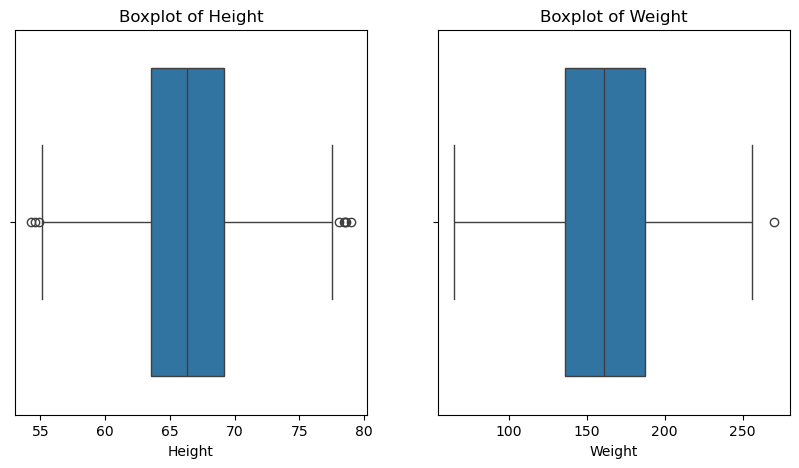

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # Use figsize for better sizing

sns.boxplot(x=df['Height'], ax=axes[0])
axes[0].set_title('Boxplot of Height') # Set individual subplot title


sns.boxplot(x=df['Weight'], ax=axes[1]) 
axes[1].set_title('Boxplot of Weight')

<Axes: xlabel='Weight', ylabel='Count'>

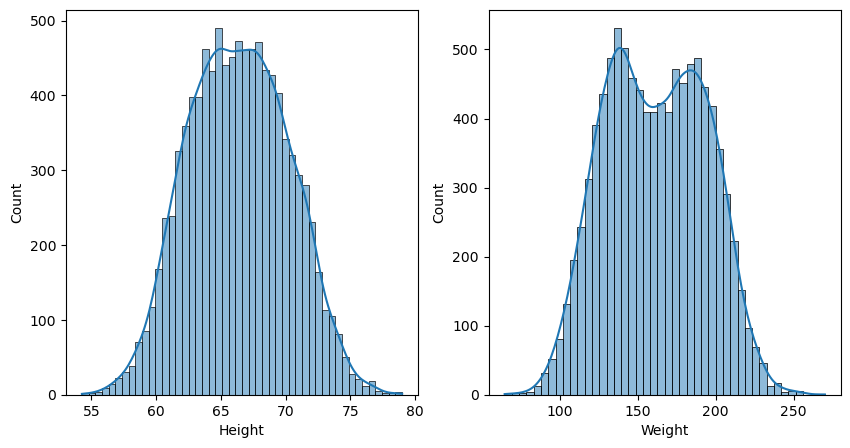

In [11]:
figu, axes = plt.subplots(1,2,figsize=(10,5))

sns.histplot(df.Height,ax=axes[0],kde=True)

sns.histplot(df.Weight,ax=axes[1],kde=True)

In [23]:
lower=df.Height.quantile(0.019)
lower

np.float64(58.87425750823421)

In [24]:
upper=df.Height.quantile(0.981)
upper

np.float64(74.03382263404801)

# Trimming

In [29]:
df[(df.Height >= upper) | (df.Weight <= lower)]

,Gender,Height,Weight
2,Male,74.110105,212.740856
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
...,...,...,...
4825,Male,74.975231,214.495489
4843,Male,74.650540,213.320520
4883,Male,74.210521,204.759344
4913,Male,74.217091,222.829851


In [28]:
new_df_t=df[(df.Height <= upper) & (df.Weight >= lower)]

In [30]:
new_df_t.shape

(9810, 3)

In [27]:
df_cols=df.columns

In [32]:
new_height_c=np.where(df.Height >= upper,
         upper,
         np.where(df.Height <= lower,
                 lower,
                 df.Height)
        )

Text(0.5, 1.0, 'New')

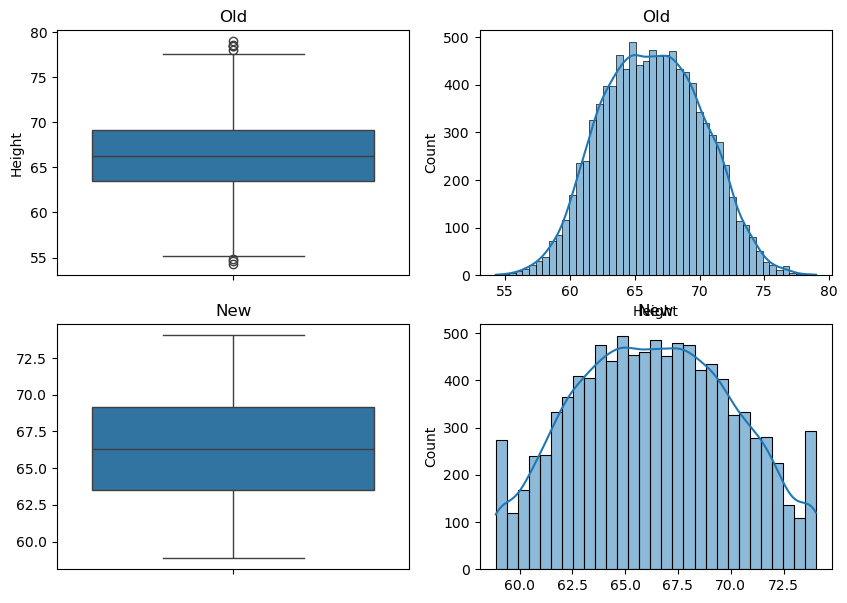

In [39]:
fi,a=plt.subplots(2,2,figsize=(10,7))
sns.boxplot(df.Height,ax=a[0][0])
sns.histplot(df.Height,ax=a[0][1],kde=True)
a[0][0].set_title("Old")
a[0][1].set_title("Old")
sns.boxplot(new_height_c,ax=a[1][0])
sns.histplot(new_height_c,ax=a[1][1],kde=True)
a[1][0].set_title("New")
a[1][1].set_title("New")
